# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [ ]:
# your code here

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [7]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

In [5]:
# summary statistics
display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

**Your formulation here:**

- X (feature space): ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'], excluding the target variable('Churn') and 'customerID'.

- y (target variable): 'Churn'

- Probability distribution of y: Bernoulli distribution (since it models binary outcomes).

- Natural loss function: Binary Cross-Entropy (Log Loss).

- Hypothesis class: Linear classifiers (e.g., Logistic Regression, Ridge Classifier).

- Assumption 1: Independent and Identically Distributed (IID) samples (each customer's data and decision to churn is independent of the others). If violated, the model's estimates will be unreliable on new data.

- Assumption 2: Linearity in log-odds. The model assumes the relationship between features and the log-odds of churning is linear. If violated, the model will underfit.

- Assumption 3: Minimal multicollinearity. The features shouldn't be perfectly correlated. If violated, the model coefficients will be highly unstable and difficult to interpret.

- Sources of uncertainty: Missing data (TotalCharges has whitespace values), Label noise (did they churn because of bad service, or just because they moved out of the country?), and Sampling bias (does this dataset represent all regions or just one segment?).

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [ ]:
# Fix TotalCharges: convert to numeric, coercing errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
# Check missing values
print(f"Missing values in TotalCharges: {df['TotalCharges'].isna().sum()}")

Missing values in TotalCharges: 11


In [11]:
# Drop rows with missing TotalCharges (only 11 rows)
df = df.dropna(subset=['TotalCharges']).copy()
print(f"Shape after dropping missing TotalCharges: {df.shape}")

Shape after dropping missing TotalCharges: (7032, 21)


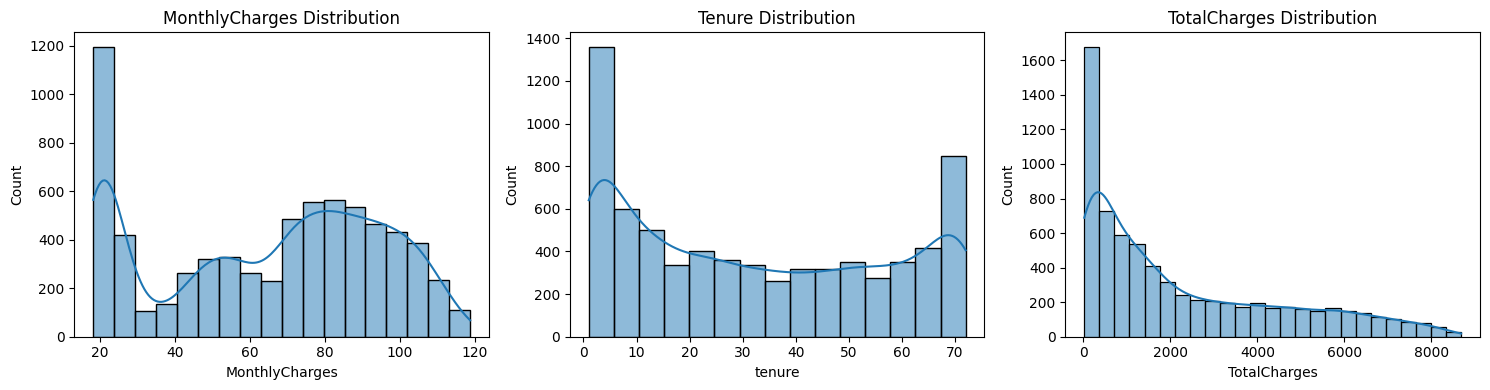

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0])
axes[0].set_title('MonthlyCharges Distribution')

sns.histplot(df['tenure'], kde=True, ax=axes[1])
axes[1].set_title('Tenure Distribution')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('TotalCharges Distribution')

plt.tight_layout()
plt.show()

In [14]:
df[['MonthlyCharges', 'tenure', 'TotalCharges']].describe()

,MonthlyCharges,tenure,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,64.798208,32.421786,2283.300441
std,30.085974,24.545260,2266.771362
min,18.250000,1.000000,18.800000
25%,35.587500,9.000000,401.450000
50%,70.350000,29.000000,1397.475000
75%,89.862500,55.000000,3794.737500
max,118.750000,72.000000,8684.800000


In [15]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

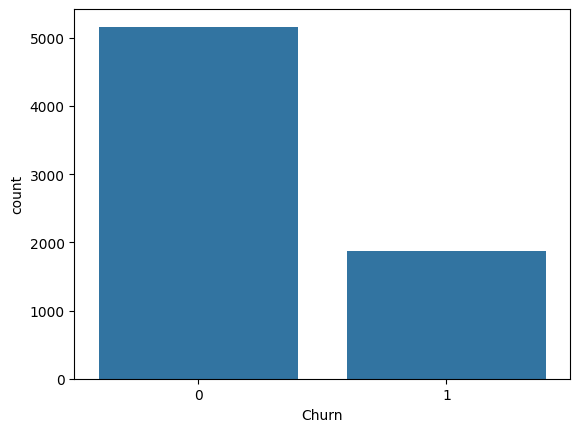

In [ ]:
# Visualize target
sns.countplot(data=df, x='Churn')
plt.show()

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score


In [24]:
# Features and target
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# Train
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X, y)  # dummy doesn't use X, but fit anyway

# Predict
y_pred_naive = dummy_clf.predict(X)

# Evaluate
acc_naive = accuracy_score(y, y_pred_naive)
recall_naive = recall_score(y, y_pred_naive)
f1_naive = f1_score(y, y_pred_naive)

In [25]:
print(f"Naive Baseline Accuracy: {acc_naive:.4f}")
print(f"Naive Baseline Recall: {recall_naive:.4f}")
print(f"Naive Baseline F1 Score: {f1_naive:.4f}")
print("\nClass distribution:\n", df['Churn'].value_counts(normalize=True))

Naive Baseline Accuracy: 0.7342
Naive Baseline Recall: 0.0000
Naive Baseline F1 Score: 0.0000

Class distribution:
 Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

No, they shouldn't be thrilled. The first question to ask is: "How many actual churners did we successfully catch?" (which is Recall). Since the ~73% accuracy comes entirely from blindly predicting "No Churn" for every single customer, the model catches 0 churners. It is completely useless for a retention team because it doesn't give them anyone to call.

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
#### Why do we use stratified splitting for a churn dataset?
- Because the dataset is imbalanced (only ~27% churn). Stratified splitting ensures that the 27% proportion is maintained across the train, validation, and test sets. If we didn't, we could end up with a validation set that randomly has almost no churners.

#### Why do we fit the scaler on training data only?
- To prevent data leakage. If we fit the scaler on the whole dataset, information about the validation and test sets (like their mean and variance) leaks into the training process.

#### What would happen if we scaled before splitting?
- Data leakage happens if we scale the whole dataset before splitting, because the scaler calculates statistics (like mean and standard deviation) using both training and test data. This indirectly gives the model information about the test set.

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop customerID
df = df.drop(columns=['customerID'])

# Define X and y
X = df.drop(columns=['Churn'])
y = df['Churn']

# One-hot encode all categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Stratified train / validation / test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, stratify=y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.50, random_state=42)

# Scale numeric features using StandardScaler, fit on training data only
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train_s = X_train.copy()
X_val_s = X_val.copy()
X_test_s = X_test.copy()

X_train_s[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_s[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_s[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Train size: {X_train_s.shape}, Val size: {X_val_s.shape}, Test size: {X_test_s.shape}")


Train size: (4922, 30), Val size: (1055, 30), Test size: (1055, 30)


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
#### What loss function does each model optimise?
- Logistic Regression: Log Loss (Binary Cross-Entropy).
- Ridge Classifier: Squared Hinge Loss (with L2 penalty).
- SGD Classifier (with loss='log_loss'): Log Loss (Binary Cross-Entropy).

#### Which model trains fastest? Does that surprise you?
- Ridge Classifier is generally the fastest because it solves the problem analytically (closed-form solution) by converting it to a regression problem under the hood, rather than iterating through gradient descent.

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [ ]:
import time
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

# Initialize models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
ridge = RidgeClassifier(random_state=42)
sgd = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)

# Train and measure time
models = {
    "Logistic Regression": log_reg,
    "Ridge Classifier": ridge,
    "SGD Classifier": sgd,
}
training_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_s, y_train)
    end_time = time.time()
    training_times[name] = end_time - start_time
    print(f"{name} trained in {training_times[name]:.4f} seconds.")


Logistic Regression trained in 0.0885 seconds.
Ridge Classifier trained in 0.0454 seconds.
SGD Classifier trained in 0.0777 seconds.


In [29]:
sorted_models = sorted(training_times.items(), key=lambda x: x[1])

print("Ranking (fastest to slowest):")
for name, t in sorted_models:
    print(name, f"{t:.4f}")

Ranking (fastest to slowest):
Ridge Classifier 0.0454
SGD Classifier 0.0777
Logistic Regression 0.0885


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss
import numpy as np

results = []

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_val_s)
    
    # Probabilities or decision function
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val_s)[:, 1]
    else:
        # Ridge has no predict_proba, use decision_function
        y_proba = model.decision_function(X_val_s)
        
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)
    pr_auc = average_precision_score(y_val, y_proba)
    
    # Log loss (only valid if we have true probabilities)
    if hasattr(model, "predict_proba"):
        ll = log_loss(y_val, y_proba)
    else:
        ll = np.nan
        
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Log Loss': ll
    })

comparison_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
2,SGD Classifier,0.807583,0.644444,0.619217,0.631579,0.850127,0.661953,0.415265
0,Logistic Regression,0.823697,0.693878,0.604982,0.646388,0.853258,0.655002,0.410468
1,Ridge Classifier,0.812322,0.686099,0.544484,0.607143,0.851143,0.649250,NaN


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
#### At what threshold does your model maximise F1?
- At threshold of 0.4343 i got maximum F1 score of 0.6535.

#### Why does the PR curve tell you more than the ROC curve for this problem?
- ROC plots TPR against FPR. In imbalanced data, True Negatives (majority class) are huge, so False Positive Rate stays very low even if False Positives are high in absolute terms. The PR curve focuses only on the positive class (Precision and Recall), which is what we care about.

#### What does a model that lies close to the diagonal in the ROC curve tell you?
- It means the model is no better than random guessing.

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


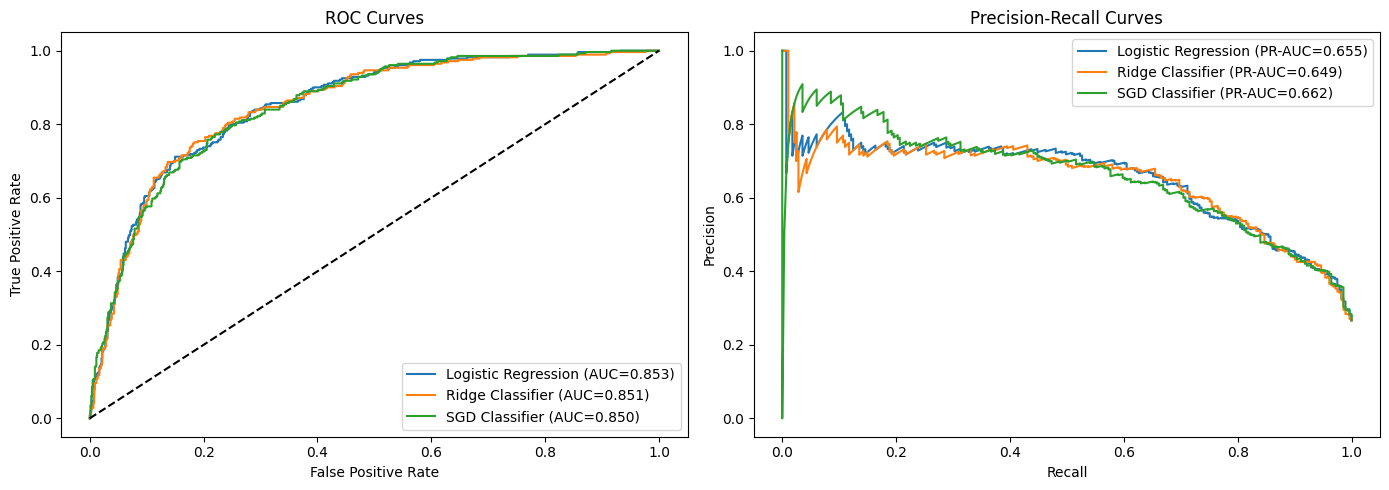

In [35]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_val_s)[:, 1]
    else:
        proba = model.decision_function(X_val_s)
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_val, proba):.3f})")
    
ax1.plot([0, 1], [0, 1], "k--")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves")
ax1.legend()

# PR
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_val_s)[:, 1]
    else:
        proba = model.decision_function(X_val_s)
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ax2.plot(
        rec, prec, label=f"{name} (PR-AUC={average_precision_score(y_val, proba):.3f})"
    )

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves")
ax2.legend()

plt.tight_layout()
plt.show()

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
#### How do you identify the top 200 highest-risk customers?
- By computing predict_proba() for all customers, sorting them in descending order, and finding the probability score of the 200th customer to use as a custom threshold.

#### What precision do you achieve at that threshold?
- At threshold of 0.5845, i achieved precision of 0.700.

#### How does this compare to the default threshold of 0.5?
- The precision is higher, but the recall is much lower in this case because we are limiting ourselves to 200 calls. This perfectly aligns with the real-world business constraint.

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [ ]:
# Using best model
best_model = models['SGD Classifier']
proba_val = best_model.predict_proba(X_val_s)[:, 1]

# Sort descending
sorted_indices = np.argsort(proba_val)[::-1]

# Threshold is the probability of the 200th highest
threshold_200 = proba_val[sorted_indices[199]]  # 0-indexed
print(f"Threshold for top 200: {threshold_200:.4f}")

# Predictions at this threshold
y_pred_200 = (proba_val >= threshold_200).astype(int)

# Predictions at threshold of 0.5
y_pred_05 = (proba_val >= 0.5).astype(int)

print(f"Default 0.5 threshold: Precision={precision_score(y_val, y_pred_05):.3f}, Recall={recall_score(y_val, y_pred_05):.3f}, F1={f1_score(y_val, y_pred_05):.3f}")
print(f"Top-200 threshold: Precision={precision_score(y_val, y_pred_200):.3f}, Recall={recall_score(y_val, y_pred_200):.3f}, F1={f1_score(y_val, y_pred_200):.3f}")

Threshold for top 200: 0.5845
Default 0.5 threshold: Precision=0.644, Recall=0.619, F1=0.632
Top-200 threshold: Precision=0.700, Recall=0.498, F1=0.582


In [46]:
thresholds = np.linspace(0, 1, 100)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred = (proba_val >= t).astype(int)
    f1 = f1_score(y_val, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Best threshold: {best_t:.4f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.4343
Best F1: 0.6535


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
#### Which features drive churn the most?
- Top Drivers: InternetService_Fiber optic is the strongest driver pushing customers to leave, while a long customer tenure is the strongest factor keeping them loyal.

#### Do the signs of the coefficients make business sense?
- The signs make complete sense because long-term habits (tenure) and binding agreements (Contract) naturally restrict or discourage a customer from canceling their service.

#### Are there any coefficients that surprise you? Investigate why.
- It is highly surprising that MonthlyCharges has a negative coefficient (around -1). This falsely implies that charging customers more money makes them less likely to churn, which defies basic business sense.

- This occurs due to multicollinearity. In our dataset, MonthlyCharges and TotalCharges are tightly linked because total charges are mathematically calculated from monthly charges over tenure.

- Because these two features provide almost identical information, the model gets confused and cannot separate their individual impacts. To balance its internal mathematical equations, the model artificially pushes TotalCharges positive and flips MonthlyCharges to a negative sign. 

- In reality, high monthly bills do not retain customers, as we can clearly see TotalCharges is increasing Churn. 

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


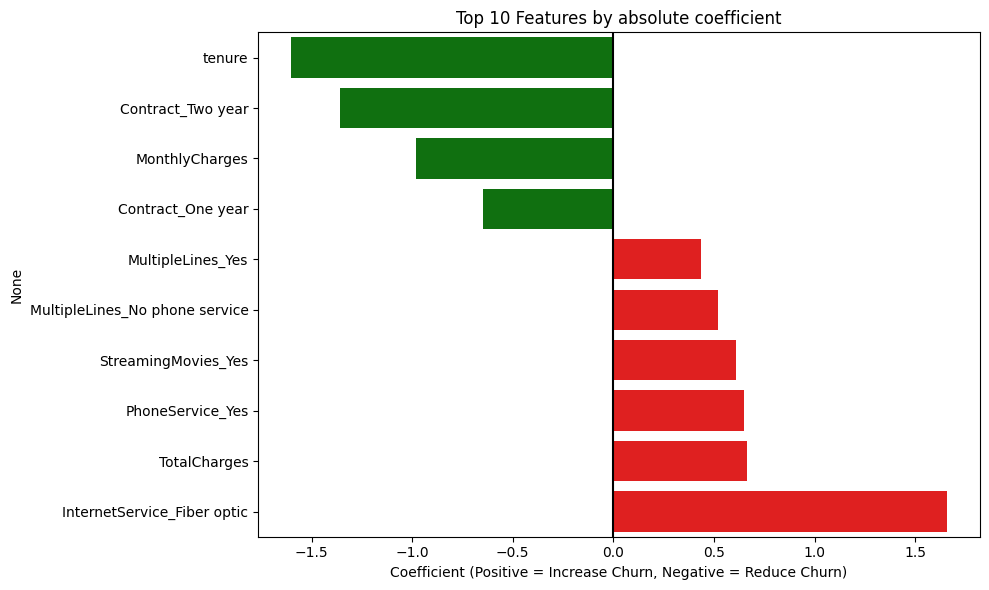

In [58]:
# Get coefficients
feature_names = X_train_s.columns
coeffs = best_model.coef_[0]

# Create series
coef_series = pd.Series(coeffs, index=feature_names)

# Take top 10 by absolute strength, but KEEP sign
top_10_signed = coef_series.loc[coef_series.abs().nlargest(10).index]

# Sort for better visualization
top_10_signed = top_10_signed.sort_values()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_signed.values,
    y=top_10_signed.index,
    hue=top_10_signed.index,
    palette=['green' if v < 0 else 'red' for v in top_10_signed.values],
)

plt.axvline(0, color='black')
plt.title('Top 10 Features by absolute coefficient')
plt.xlabel('Coefficient (Positive = Increase Churn, Negative = Reduce Churn)')
plt.tight_layout()
plt.show()

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
#### Do they produce the same predictions? Same coefficients?
- Same predictions: Roughly, yes. The predictive performance is nearly identical, as shown by the very close AUC scores (0.8533 for Logistic Regression vs. 0.8501 for SGD).
- Same Coefficients? No. This is because Logistic Regression calculates the exact mathematical solution using all data at once, whereas SGD uses random, iterative steps that stop once the results are "good enough," leading to different final weights.

#### Which is faster?
-  Logistic Regression is faster (0.0269s) compared to SGD (0.0851s) for this specific dataset. Standard Logistic Regression is more efficient on smaller datasets that easily fit entirely into the computer's memory.

#### Under what conditions would you prefer SGD?
- Massive Datasets: When the data size exceeds available RAM, because SGD can process data sequentially in small chunks (online learning).

- High-Dimensional Features: When dealing with text classification or sparse datasets with tens of thousands of features.

- Streaming Data: When the model needs to update its weights continuously in real-time as new data arrives, without retraining from scratch.

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [ ]:
# Compare LogisticRegression (Batch) vs SGDClassifier (Stochastic)
sgd = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)
sgd_start = time.time()
sgd.fit(X_train_s, y_train)
sgd_total_time = time.time() - sgd_start

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg_start = time.time()
log_reg.fit(X_train_s, y_train)
log_reg_total_time = time.time() - log_reg_start

# Predict
log_reg_proba = log_reg.predict_proba(X_val_s)[:, 1]
sgd_proba = sgd.predict_proba(X_val_s)[:, 1]

print(f"Logistic Regression AUC: {roc_auc_score(y_val, log_reg_proba):.4f}")
print(f"SGD Classifier AUC: {roc_auc_score(y_val, sgd_proba):.4f}")

# Check coefficient convergence
are_close = np.allclose(log_reg.coef_, sgd.coef_, atol=0.15)
print(f"Are coefficients roughly the same? {are_close}")

# Compare training times
print(f"LR time: {log_reg_total_time:.4f}s, SGD time: {sgd_total_time:.4f}s")

Logistic Regression AUC: 0.8533
SGD Classifier AUC: 0.8501
Are coefficients roughly the same? False
LR time: 0.0269s, SGD time: 0.0851s


---

## 💬 Discussion 

#### **Which model do you deploy? Why not the others?**  
- I would Deploy SGD Classifier because: 
- It has Highest PR-AUC (0.6619): On this imbalanced dataset, the SGD Classifier outperforms both Logistic Regression (0.6550) and Ridge Classifier (0.6492).
- It has Highest Recall (0.6192).

#### **Does SGD converge to the same solution as full-batch LR? Why might it not?**
- No, SGD does not converge to the exact same solution as full-batch Logistic Regression.
- Why it might not:
- Full-batch Logistic Regression processes every single row of data simultaneously to find the absolute mathematical center. SGD calculates its gradient using only a single random row (or small batch).
- SGD updates its weights step-by-step. Once the performance improvements drop below a predefined tolerance limit (tol), it terminates training early and settles for a "good enough" approximation.

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
#### What distribution does your regression target follow?
- The target follows a bimodal distribution that forms a U-shape.There is a heavy concentration of short-term customers at the beginning (0–5 months) and another large concentration of long-term customers at the end (65–72 months), with a lower, stable volume in between.

#### What does CLV tell the business that binary churn prediction cannot?
- CLV quantifies the financial value at risk, allowing the business to prioritize retention spend based on dollar amounts rather than just a yes/no probability. 
- A binary model treats a customer paying $150/month and a customer paying $15/month exactly the same if they have the same churn probability. 
- CLV multiplies risk by revenue, showing that losing the first customer hurts the business ten times more than losing the second.

#### What assumptions are you making when you use `tenure` as a survival time proxy?
- We assume that historical MonthlyCharges remain perfectly fixed and stable throughout the entire duration of the customer's lifespan.
- We assume that the factors influencing customer retention scale at a constant, linear rate over time rather than fluctuating due to seasonal trends or market competition.

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


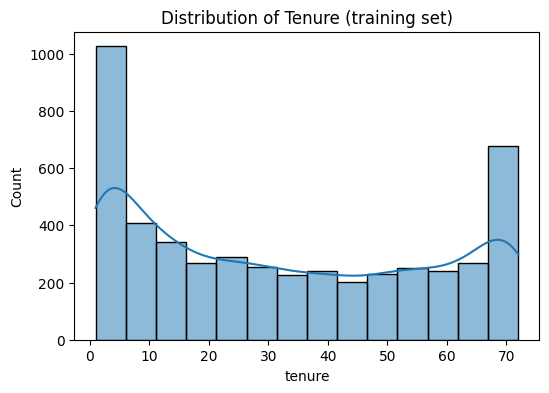

In [64]:
# Target variable for regression
y_train_reg = X_train['tenure']
y_val_reg = X_val['tenure']

# Drop 'tenure' from features to avoid target leakage!
X_train_reg = X_train_s.drop(columns=['tenure'])
X_val_reg = X_val_s.drop(columns=['tenure'])

# Plot distribution of tenure
plt.figure(figsize=(6,4))
sns.histplot(y_train_reg, kde=True)
plt.title('Distribution of Tenure (training set)')
plt.show()

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
#### Which model performs best? By how much?
- Lasso performs best on average error, while Linear Regression performs best on variance explanation. 
- Lasso achieves the lowest Mean Absolute Error (MAE = 6.774199), beating Linear Regression (6.817945). 
- However, Linear Regression achieves the highest coefficient of determination ($R^2$ = 0.864684), outperforming Lasso (0.862503) by a marginal 0.21%.

#### What does R² = 0.55 actually mean in this context?
- An $R^2 = 0.55$ means that 55% of the variance in customer tenure can be predicted and explained by the features in the model. The remaining 45% of the variance is completely unexplained and is driven by external factors not captured in the dataset.

#### Is RMSE or MAE more appropriate here? Why?
- MAE is more appropriate here.
- Because, The tenure distribution shows a bimodal U-shape with huge clusters of customers concentrated at the extreme ends (0–5 months and 65–72 months). Because a linear model trying to fit this data will naturally make large errors on these extreme groups, RMSE will heavily over-punish those unavoidable errors due to its squaring mechanism ($\text{Error}^2$). MAE measures the absolute, actual average error in original units (months), making it more robust to these extreme structural variations and much easier to explain directly to business stakeholders.

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [68]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.1, random_state=42),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_val_reg)

    mae = mean_absolute_error(y_val_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_reg))
    r2 = r2_score(y_val_reg, y_pred_reg)

    reg_results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})

reg_df = pd.DataFrame(reg_results).sort_values(by="R²", ascending=False)
display(reg_df)

,Model,MAE,RMSE,R²
0,Linear Regression,6.817945,8.914638,0.864684
1,Ridge,6.816829,8.915379,0.864662
2,Lasso,6.774199,8.986199,0.862503
3,Elastic Net,6.886983,9.312026,0.852352


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


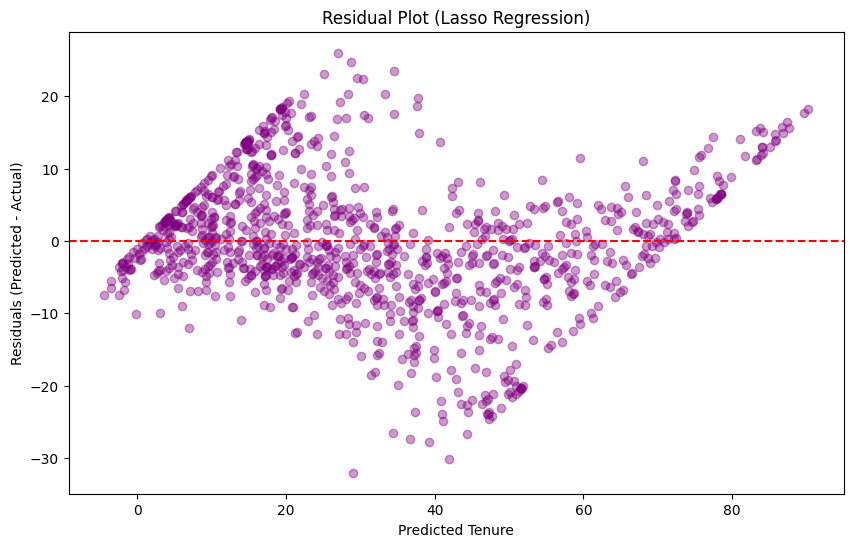

In [69]:
# Let's use Lasso as our best regression model
best_reg = reg_models['Lasso']
y_pred_reg = best_reg.predict(X_val_reg)

# Calculate residuals
residuals = y_pred_reg - y_val_reg

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_reg, residuals, alpha=0.4, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Tenure")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("Residual Plot (Lasso Regression)")
plt.show()


---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


d:\journey\fusemachines\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.523e+05, tolerance: 2.975e+02
  model = cd_fast.enet_coordinate_descent(


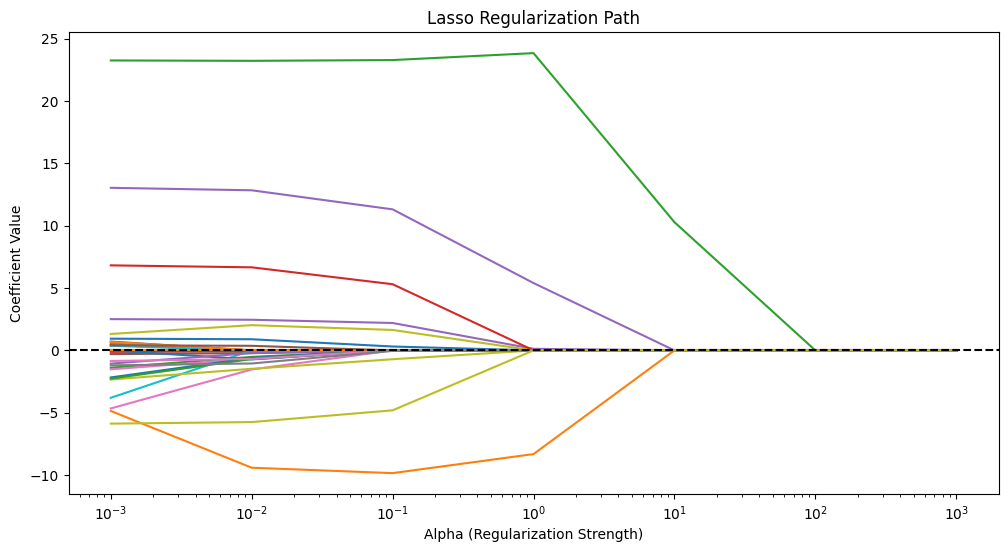

In [79]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, random_state=42)
    lasso.fit(X_train_reg, y_train_reg)
    lasso_coefs.append(lasso.coef_)


plt.figure(figsize=(12, 6))
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regularization Path')
plt.axhline(0, color='black', linestyle='--')
plt.show()


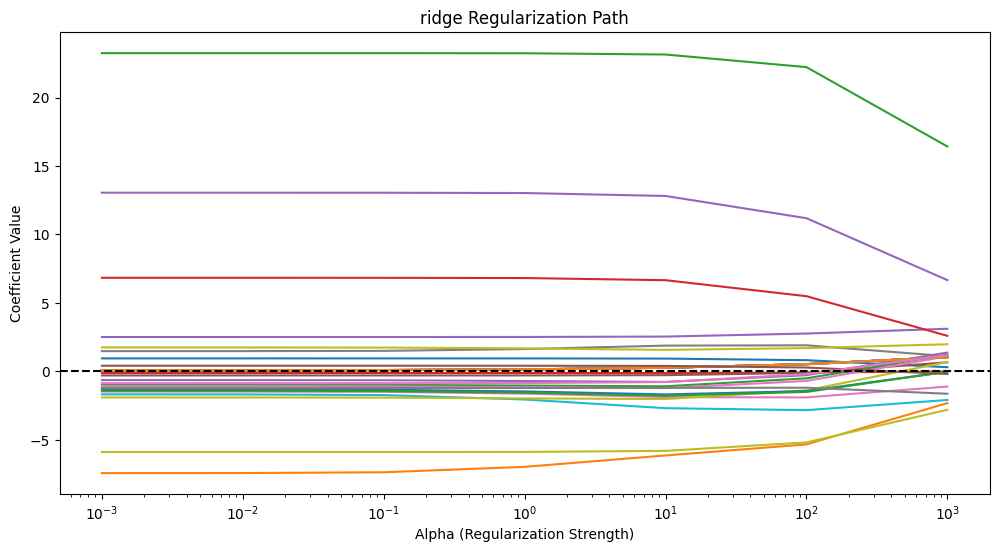

In [77]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_train_reg, y_train_reg)
    ridge_coefs.append(ridge.coef_)

plt.figure(figsize=(12, 6))
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('ridge Regularization Path')
plt.axhline(0, color='black', linestyle='--')
plt.show()


---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
#### What is the mean and median CLV?
- Mean CLV: $2171.77
- Median CLV: $1161.61

#### What does CLV enable the business to do that binary prediction cannot?
- It allows the business to prioritise retention efforts by revenue impact. Instead of just calling the people most likely to leave, they can call the people who are likely to leave and whats their value to company. 

#### Why must you clip negative predicted tenure values to 0?
- Because a negative tenure is physically impossible and would result in a negative CLV, which breaks the business logic.

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [ ]:
# Calculate CLV for the validation set (CLV = MonthlyCharges * predicted tenure)

# Get actual MonthlyCharges from the original validation set before scaling
monthly_charges_val = X_val["MonthlyCharges"]

# Predict tenure and clip negative values to 0
pred_tenure = best_reg.predict(X_val_reg)
pred_tenure = np.maximum(pred_tenure, 0)

# Calculate CLV
clv = monthly_charges_val * pred_tenure

print(f"Mean CLV: ${clv.mean():.2f}")
print(f"Median CLV: ${clv.median():.2f}")

# Compare high CLV churners vs low CLV churners
val_results = pd.DataFrame(
    {
        "Actual Churn": y_val,
        "Predicted Churn Prob": log_reg.predict_proba(X_val_s)[:, 1],
        "CLV": clv,
    }
)

top_value_churners = val_results[
    (val_results["Predicted Churn Prob"] > 0.5)
].sort_values(by="CLV", ascending=False)

display(top_value_churners.head())


Mean CLV: $2171.77
Median CLV: $1161.61


,Actual Churn,Predicted Churn Prob,CLV
6009,1,0.559502,5418.959195
3910,1,0.560824,4807.698009
1926,1,0.504805,4682.422184
1663,1,0.542024,4541.605917
1770,1,0.538397,4392.504084


---

## 💬 Discussion

#### **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
- An $R^2 = 0.55$ means that 55% of the variance in customer tenure can be predicted and explained by the features in the model. The remaining 45% of the variance is completely unexplained and is driven by external factors not captured in the dataset.
- R² of 0.55 means there is a lot of variance we aren't capturing, so I would be cautious about deploying it as a definitive measure.

#### **Your Lasso dropped several features. Is that a good outcome or a warning sign?**
- As for Lasso dropping features, that is a good outcome because it acts as automatic feature selection, removing noise, preventing overfitting, and making the model simpler to interpret.

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [81]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    models["SGD Classifier"], X_train_s, y_train, cv=cv, scoring="roc_auc"
)
print(f"5-fold CV ROC-AUC: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

# Compare with holdout validation AUC
holdout_auc = roc_auc_score(y_val, best_model.predict_proba(X_val_s)[:, 1])
print(f"Holdout ROC-AUC: {holdout_auc:.4f}")

5-fold CV ROC-AUC: mean=0.8384, std=0.0169
Holdout ROC-AUC: 0.8501


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


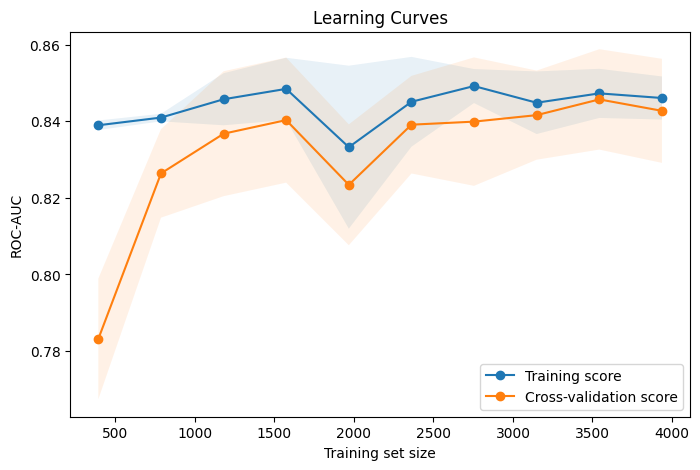

In [82]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_s,
    y_train,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, val_mean, "o-", label="Cross-validation score")
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curves")
plt.legend()
plt.show()

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [83]:
# Step 1: Record baseline metrics
baseline_auc = roc_auc_score(y_val, best_model.predict_proba(X_val_s)[:,1])
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")

Baseline ROC-AUC: 0.8501


In [ ]:
# Step 2: Create and add the leakage feature
# Leakage: tenure * churn + noise

X_train_leak = X_train["tenure"] * y_train + np.random.normal(0, 0.1, len(y_train))
X_train_leaked = np.column_stack([X_train_s, X_train_leak])

X_val_leak = X_val["tenure"] * y_val + np.random.normal(0, 0.1, len(y_val))
X_val_leaked = np.column_stack([X_val_s, X_val_leak])

In [85]:
# Step 3: Retrain on the same split and record metrics
model_leaked = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)
model_leaked.fit(X_train_leaked, y_train)

leaked_auc = roc_auc_score(y_val, model_leaked.predict_proba(X_val_leaked)[:,1])
print(f"With leakage ROC-AUC: {leaked_auc:.4f}")

With leakage ROC-AUC: 1.0000


In [94]:
# Step 4: Show feature importances — does the leakage feature dominate?
print(f"model coefficients: {model_leaked.coef_[0]}")

# last coefficient is leakage
print(f"Leakage coefficient: {model_leaked.coef_[0][-1]:.4f}")

# Yes this leakage coefficient dominates all.

model coefficients: [ 0.26561773 -3.28458626 -0.54988312 -2.27004574  0.25683079  0.26188147
 -0.03533493  1.07688584  0.48995505  0.11238707  0.77628095 -0.14024879
 -0.14024879 -0.19572796 -0.14024879 -0.1746574  -0.14024879 -0.30276498
 -0.14024879 -0.20470873 -0.14024879  0.02372322 -0.14024879  0.35098525
 -0.56276985 -0.30501824  0.49147858 -0.02868508  0.78177981  0.6988649
  9.12395739]
Leakage coefficient: 9.1240


In [108]:
# Remove last column (leakage feature)
X_train_leak_removed = X_train_leaked[:, :-1]
X_val_leak_removed = X_val_leaked[:, :-1]

# Retrain model
model_leak_removed = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)

model_leak_removed.fit(X_train_leak_removed, y_train)

# Evaluate
leak_removed_auc = roc_auc_score(y_val, model_leak_removed.predict_proba(X_val_leak_removed)[:, 1])

print(f"With leakage removed ROC-AUC: {leak_removed_auc:.4f}")

With leakage removed ROC-AUC: 0.8501


In [109]:
summary = pd.DataFrame({
    'Condition': ['No Leakage', 'With Leakage', 'With leakage removed'],
    'ROC-AUC': [baseline_auc, leaked_auc, leak_removed_auc]
})
summary

,Condition,ROC-AUC
0,No Leakage,0.850127
1,With Leakage,1.000000
2,With leakage removed,0.850127


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [ ]:
# your code here

In [ ]:
# your code here

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
